<a href="https://colab.research.google.com/github/itz-Amy/Lab-3-Neural-Networks/blob/main/Amy_Addo_Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu



# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

# Part 1.1 — A single neuron is just a line

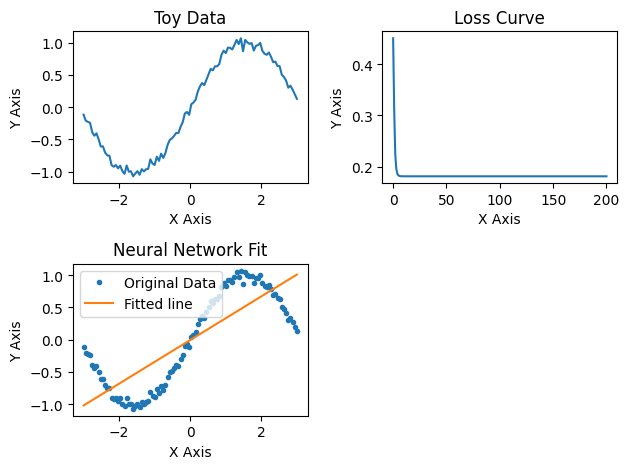

In [ ]:

# TODO: Generate the toy data
x = np.linspace(-3, 3, 100)

y = np.sin(x) + np.random.normal(0, 0.05, size=x.shape)


#   Plot it.

plt.subplot(2, 2, 1)
plt.plot(x, y)
plt.xlabel("X Axis")
plt.ylabel("Y Axis")
plt.title("Toy Data")

# TODO: Initialise w and b to small random values.

w = np.random.rand() * 0.1
b = np.random.rand() * 0.1

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:

y_hat = w * x + b
lr = 0.05
losses = []

loss  = np.mean((y_hat - y) ** 2)               # MSE
dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
db    = np.mean(2 * (y_hat - y))                # dLoss/db
w    -= lr * dw
b    -= lr * db
losses.append(loss)

#   Record the loss at every step.
for i in range(200):
  y_hat = w * x + b
  lr = 0.07
  loss  = np.mean((y_hat - y) ** 2)
  dw    = np.mean(2 * (y_hat - y) * x)
  db    = np.mean(2 * (y_hat - y))
  w    -= lr * dw
  b    -= lr * db
  losses.append(loss)


# TODO: Plot

#  (a) the loss curve over the 200 steps, and
# plt.plot(x, y_hat)
plt.subplot(2, 2, 2)
plt.plot(losses)
plt.xlabel("X Axis")
plt.ylabel("Y Axis")
plt.title("Loss Curve")

#  (b) the data with the fitted line on top.
plt.subplot(2, 2, 3)
plt.plot(x, y, '.', label="Original Data")
plt.plot(x, y_hat, '-', label="Fitted line")
plt.title("Neural Network Fit")
plt.xlabel("X Axis")
plt.ylabel("Y Axis")
plt.legend()
plt.tight_layout()
plt.show()




1. Derive dLoss/dw on paper and include a photo or the LaTeX in this cell — does it match the code?    
Yes the derivative matches the code.

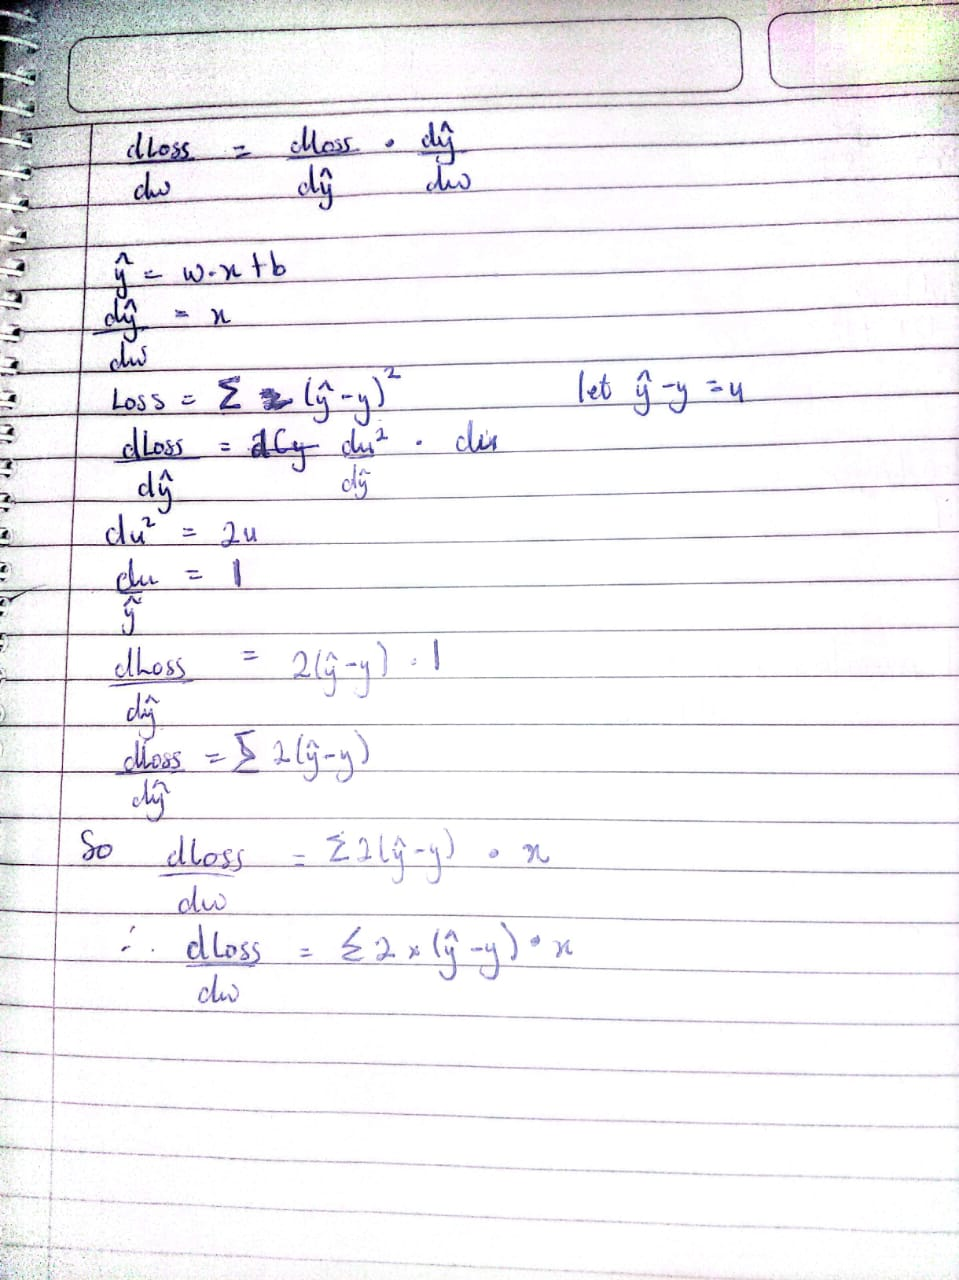

2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting, and WHY can a single neuron never fit a sine wave, no matter how long you train?
The model underfitted even though the loss kept improving. The underfitting was because the inputs were passed through a linear model so the only output the model could give was a linear one evnen though the data was clearly non linear. A single neuron can not fit the wave no matter how long it is trained because it won't be able to learn the non linearity aspects of the data.


# Part 1.2 — Hidden layers and activations: why depth helps

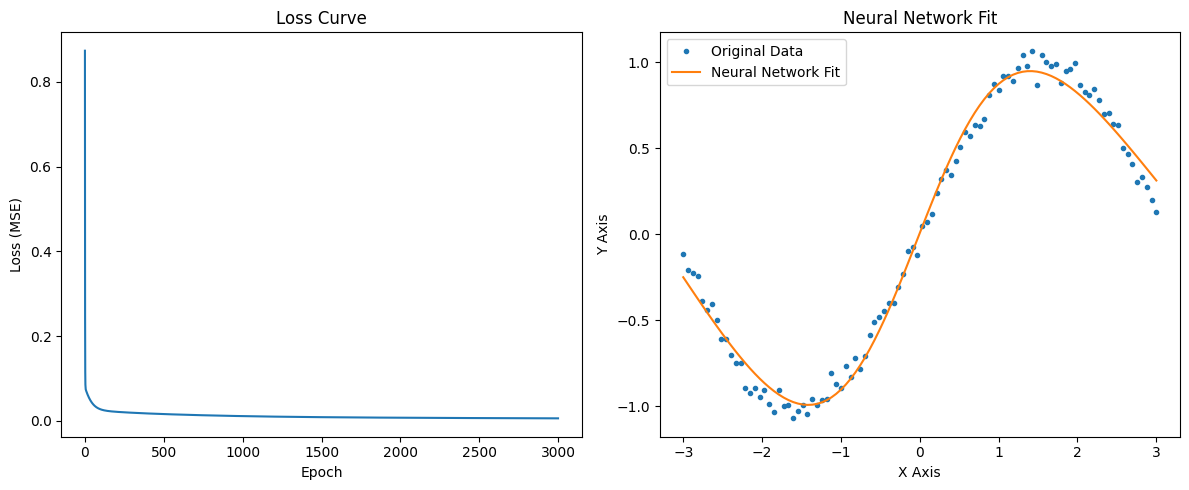

In [ ]:
# TODO: Initialise parameters

# Small random values (e.g. np.random.randn(...) * 0.5)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8,) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1,) * 0.5


x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

losses = []
# TODO: Forward pass (keep the intermediate values — you need them for backprop):
z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
h  = np.tanh(z1)        # activation
y_hat = h @ W2 + b2     # output, shape (100, 1)
loss  = np.mean((y_hat - y) ** 2)

# TODO: Backward pass (the chain rule, layer by layer):
d_yhat = 2 * (y_hat - y) / len(y)
dW2 = h.T @ d_yhat
db2 = d_yhat.sum(axis=0)
dh  = d_yhat @ W2.T
dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
dW1 = x.T @ dz1
db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr,

W1 -= lr * dW1
b1 -= lr * db1
W2 -= lr * dW2
b2 -= lr * db2



# loop for ~3000 steps,
for epoch in range(3000):
    # Forward pass
    z1 = x @ W1 + b1
    h  = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss  = np.mean((y_hat - y) ** 2)
    losses.append(loss)   #   record the loss.

    # Backward pass (the chain rule, layer by layer)
    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh  = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    # Update all parameters with learning rate
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2



# Plot the loss curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")

# Plot the final fit over the data
plt.subplot(1, 2, 2)
plt.plot(x, y, '.', label="Original Data")
plt.plot(x, y_hat, '-', label="Neural Network Fit")
plt.title("Neural Network Fit")
plt.xlabel("X Axis")
plt.ylabel("Y Axis")
plt.legend()
plt.tight_layout()
plt.show()



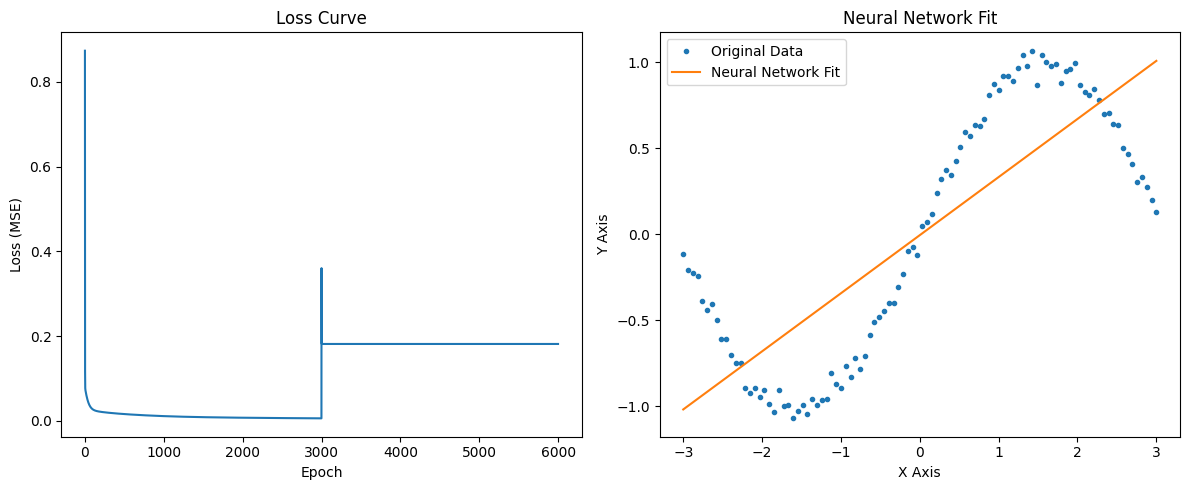

In [ ]:

W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8,) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1,) * 0.5


x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
for epoch in range(3000):
    # Forward pass
    z1 = x @ W1 + b1
    h  = z1
    y_hat = h @ W2 + b2
    loss  = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    # Backward pass (the chain rule, layer by layer)
    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh  = d_yhat @ W2.T
    dz1 = dh * 1
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    # Update all parameters with learning rate
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2



# Plot the loss curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")

# Plot the final fit over the data
plt.subplot(1, 2, 2)
plt.plot(x, y, '.', label="Original Data")
plt.plot(x, y_hat, '-', label="Neural Network Fit")
plt.title("Neural Network Fit")
plt.xlabel("X Axis")
plt.ylabel("Y Axis")
plt.legend()
plt.tight_layout()
plt.show()


 1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1. Explain mathematically why a stack of linear layers collapses into one linear layer.
 A linear function of a linear function is still linear. No matter how many layers, the network would be equivalent to a single linear regression model.
 Without the non linear activation the network can't bend and represent curves that are in real data.


 2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few columns of h against x.)
The 8 neurons in the hidden layer detect certain aspects of the data that would help draw out a line to fit the curve. Each layer trys to learn something different from the data to add on to what previous layers have passed on.



 3. This is exactly what loss.backward() will automate in Section 2. In one sentence, what is backpropagation?
 Back propagation is the model trying to adjust its randomly assigned weights to reduce loss and optimise predictions.

# Part 1.3 — The learning rate: too cold, too hot, just right

In [ ]:
from typing import Any, Dict, Iterable, List, Optional, Tuple
def train_toy(lr, steps=3000)-> List[int]:

    x = np.linspace(-3, 3, 100)

    y = np.sin(x) + np.random.normal(0, 0.05, size=x.shape)


    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.random.randn(8,) * 0.5
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.random.randn(1,) * 0.5

    x = x.reshape(-1, 1)
    y = y.reshape(-1, 1)

    losses = []
    for i in range(steps):
      z1 = x @ W1 + b1
      h  = z1
      y_hat = h @ W2 + b2
      loss  = np.mean((y_hat - y) ** 2)
      losses.append(loss)

      # Backward pass (the chain rule, layer by layer)
      d_yhat = 2 * (y_hat - y) / len(y)
      dW2 = h.T @ d_yhat
      db2 = d_yhat.sum(axis=0)

      dh  = d_yhat @ W2.T
      dz1 = dh * 1
      dW1 = x.T @ dz1
      db1 = dz1.sum(axis=0)

      # Update all parameters with learning rate
      W1 -= lr * dW1
      b1 -= lr * db1
      W2 -= lr * dW2
      b2 -= lr * db2

    return losses

Training with learning rate of : LR 0.001
Training with learning rate of : LR 0.05
Training with learning rate of : LR 1.0


/tmp/ipykernel_2049/4050022261.py:21: RuntimeWarning: overflow encountered in matmul
  y_hat = h @ W2 + b2
/tmp/ipykernel_2049/4050022261.py:21: RuntimeWarning: invalid value encountered in matmul
  y_hat = h @ W2 + b2


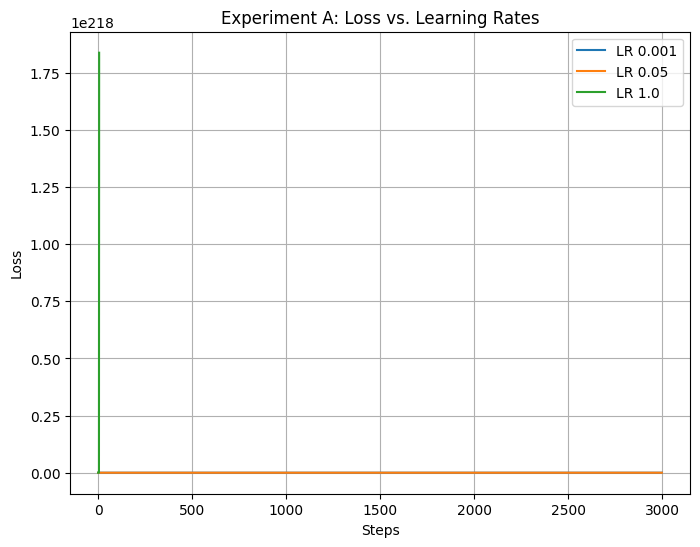

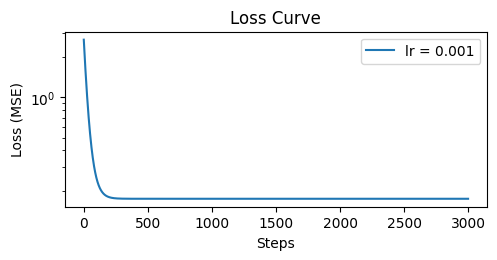

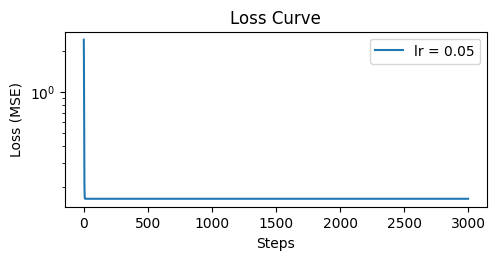

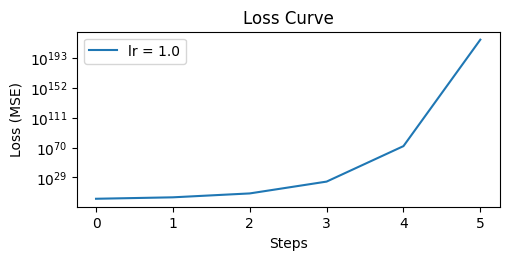

In [ ]:
# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
learning_rates = {
    'LR 0.001': 0.001,
    'LR 0.05': 0.05,
    'LR 1.0': 1.0
}


# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.


loss = {}
for name, lr_value in learning_rates.items():
    print(f"Training with learning rate of : {name}")
    torch.manual_seed(RANDOM_STATE)
    loss[name] = train_toy(lr = lr_value)


plt.figure(figsize=(8, 6))
for name, history in loss.items():
    plt.plot(loss[name], label=name)
plt.title('Experiment A: Loss vs. Learning Rates')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(2, 2, 1)
plt.plot(loss['LR 0.001'], label='lr = 0.001')
plt.title('Loss Curve')
plt.xlabel('Steps')
plt.ylabel('Loss (MSE)')
plt.yscale('log')
plt.legend()



plt.figure(figsize=(12, 5))
plt.subplot(2, 2, 2)
plt.plot(loss['LR 0.05'], label='lr = 0.05')
plt.title("Loss Curve")
plt.xlabel("Steps")
plt.ylabel("Loss (MSE)")
plt.yscale('log')
plt.legend()

plt.figure(figsize=(12, 5))
plt.subplot(2, 2, 3)
plt.plot(loss['LR 1.0'], label='lr = 1.0')
plt.title("Loss Curve")
plt.xlabel("Steps")
plt.ylabel("Loss (MSE)")
plt.yscale('log')
plt.legend()







Describe what each of the three curves shows. Why does a too-large learning rate make the loss explode or oscillate instead of just "learning faster"?
lr = 0.001, 0.05, 1.0

For the lr = 0.001 the loss curve shows a study decrease in the los for the steps taken

For the lr = 0.05 the loss curve was slightly similar to the 0.001 learning rate graph. The graph shows that at step = 0  there was an abrupt decrease in the loss and a consistent loss value from there on.

For the lr = 1.0 the loss curve was seen rising or increasing instead of decreasing. This was indicating that due to the fact that the step/ learning rate was too huge that it may heve skipped over the optimal point.


# **Section 2 — A Real Feedforward Network in PyTorch**

# Part 2.1— Preprocess and split (recycled from Lab 2)

In [ ]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

obesity = pd.read_csv(OBESITY_URL)



In [ ]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.

obesity_model_1 = obesity

obesity_model_2 = pd.get_dummies(obesity_model_1,
    columns=[
        "family_history_with_overweight",              # binary columns
        "FAVC",
        "SMOKE",
        "SCC"
    ],
    drop_first = True,
     dtype=int
)


obesity_model_3 = pd.get_dummies(obesity_model_2,
    columns=[
        "Gender",
        'MTRANS'
    ],
    drop_first = True,
    dtype=int
)


obesity_model_3["CAEC"].unique()
obesity_model_3["CALC"].unique()

encoder = OrdinalEncoder(
    categories=[[
        "no",
        "Sometimes",
        'Frequently',
        "Always"
    ]]
)

obesity_model_3["CAEC"] = encoder.fit_transform(
    obesity_model_3[["CAEC"]]
).astype(int)

obesity_model_3["CALC"] = encoder.fit_transform(
    obesity_model_3[["CALC"]]
).astype(int)




obesity_model_3["NObeyesdad"].unique()

encoder1 = OrdinalEncoder(
    categories=[[
        "Insufficient_Weight",
        "Normal_Weight",
        "Overweight_Level_I",
        "Overweight_Level_II",
        'Obesity_Type_I',
        "Obesity_Type_II",
        "Obesity_Type_III"
    ]]
)

obesity_model_3["NObeyesdad"] = encoder1.fit_transform(
    obesity_model_3[["NObeyesdad"]]
).astype(int)

obesity_model_3.head().T


,0,1,2,3,4
Age,21.00,21.00,23.0,27.0,22.00
Height,1.62,1.52,1.8,1.8,1.78
Weight,64.00,56.00,77.0,87.0,89.80
FCVC,2.00,3.00,2.0,3.0,2.00
NCP,3.00,3.00,3.0,3.0,1.00
CAEC,1.00,1.00,1.0,1.0,1.00
CH2O,2.00,3.00,2.0,2.0,2.00
FAF,0.00,3.00,2.0,2.0,0.00
TUE,1.00,0.00,1.0,0.0,0.00
CALC,0.00,1.00,2.0,2.0,1.00


In [ ]:
import sklearn.preprocessing
from sklearn.model_selection import train_test_split
# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).


X = obesity_model_3.drop(columns=["NObeyesdad"])
y_clf = obesity_model_3["NObeyesdad"]



X_temp, X_test_clf, y_temp_clf, y_test_clf = train_test_split(
    X, y_clf,
    test_size=0.4,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

#Train and validation
X_train_clf, X_val_clf, y_train_clf, y_val_clf = train_test_split(
    X_temp, y_temp_clf,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_temp_clf
)

# Scaling
from sklearn.preprocessing import StandardScaler
scaler_clf = StandardScaler()

X_train_scaled_clf = scaler_clf.fit_transform(X_train_clf)
X_val_scaled_clf = scaler_clf.transform(X_val_clf)
X_test_scaled_clf = scaler_clf.transform(X_test_clf)




In [ ]:

# TODO: Convert to tensors and wrap in DataLoaders:
X_train_tensor = torch.tensor(X_train_scaled_clf, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_clf.values, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_scaled_clf, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_clf.values, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled_clf, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_clf.values, dtype=torch.long)


# TensorDatasets
train_ds = TensorDataset(X_train_tensor, y_train_tensor)
val_ds = TensorDataset(X_val_tensor, y_val_tensor)
test_ds = TensorDataset(X_test_tensor, y_test_tensor)

# DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)


1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in PyTorch?    
Storing one-hot vectors scales poorly as the number of classes grows. This becomes a bottleneck during training batch creation
Also because using a one-hot vector, y1 is 0 for every incorrect class and 1 for the single correct class, Multiplying zero by it is mathematically pointless because it always equals zero and this could contribute to vanishing gradients


2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care so much? Connect your answer to the gradient formulas you wrote in Section 1.    
The neural networks care about feature scaling because without it the model could overfit its predictions.
Also, because each input would have weights attached to them unscaled features would give a false signal / importance about a charcteristic. Scaling puts every feature on the same level for a fair contribution for the model to learn.

3. What does shuffle=True on the training DataLoader do, and why does it help?    
It helps to randomise the sets of data in the dataset for the training, validation and test. It prevents the model from overfitting/memorising. The shuffle also ensures that be able to generalise as the model sees random unrelated data in the training set.

# `Part 2.2— Design the network`

In [ ]:
import torch.nn.functional as F

input_dim = X_train_tensor.shape[1]
NUM_CLASSES = int(y_train_tensor.max().item() + 1)

class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_dim, hidden_sizes[0])
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.fc3 = nn.Linear(hidden_sizes[1], n_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# TODO: Instantiate, move to DEVICE, print the model.
model = FeedForwardNet(input_dim = input_dim, hidden_sizes = (784,128), n_classes=NUM_CLASSES)
model.to(DEVICE)
print(model)

# TODO: Count trainable parameters:

print(f"Number of trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")




FeedForwardNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=19, out_features=784, bias=True)
  (fc2): Linear(in_features=784, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=7, bias=True)
)
Number of trainable parameters: 117063


 1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.
fc1 - 1st Layer
19*784+784 = 15,680

fc2 - 2nd Layer
784*128+128 = 100,480

fc3  - 3rd Layer
128*7+7= 903

total model parameter = 15,680 + 100,480 + 903
= 117063

this is equal to what Pytorch gave.

 2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.    
 ReLU solves the vanishing gradient problem associaited with tanh since gradient would only ever be 1 for positive inputs. This makes sure that the  gradient would always be significant. It is also cheaper to compute
 Advantage ->
 Gradient = 1 for positive inputs so no vanishing gradient

 3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)   
 Since the ReLU introduces a form of nonlinearity to the data, without it, the model would compute only a linear transformation. This is similar to removing the tanh in part 1.2.

# Part 2.3— The training loop

In [ ]:
import torch.optim as optim
from sklearn.metrics import accuracy_score

# TODO:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 50

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_va_acc =0.0
best_model_state = None

# TODO: Train for at least 50 epochs.
for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        preds = outputs.argmax(1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    tr_loss= running_loss / total
    tr_acc = correct / total
    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)


    # Validation
    model.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            outputs = model(xb)
            loss = criterion(outputs, yb)

            running_val_loss += loss.item() * xb.size(0)
            preds = outputs.argmax(1)
            correct_val += (preds == yb).sum().item()
            total_val += yb.size(0)


    va_loss = running_val_loss / total_val
    va_acc = correct_val / total_val
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    print(f"Epoch {epoch + 1 :2d}/{epochs} | "
          f"Train loss {tr_loss:.3f}, Train Acc: {tr_acc:.3f} | "
          f"Val loss {va_loss:.3f}, Val Acc: {va_acc:.3f}"
          )
  # TODO: Save the best model (highest validation accuracy):
    if va_acc > best_va_acc:
        best_va_acc = va_acc
        best_model_state = model.state_dict()
        torch.save(best_model_state, "ffn_best.pt")
        print(f"  -> New best model saved with Val Acc: {best_va_acc:.3f}")




Epoch  1/50 | Train loss 1.329, Train Acc: 0.535 | Val loss 0.884, Val Acc: 0.650
  -> New best model saved with Val Acc: 0.650
Epoch  2/50 | Train loss 0.730, Train Acc: 0.742 | Val loss 0.679, Val Acc: 0.744
  -> New best model saved with Val Acc: 0.744
Epoch  3/50 | Train loss 0.513, Train Acc: 0.828 | Val loss 0.514, Val Acc: 0.839
  -> New best model saved with Val Acc: 0.839
Epoch  4/50 | Train loss 0.377, Train Acc: 0.877 | Val loss 0.426, Val Acc: 0.870
  -> New best model saved with Val Acc: 0.870
Epoch  5/50 | Train loss 0.294, Train Acc: 0.910 | Val loss 0.373, Val Acc: 0.886
  -> New best model saved with Val Acc: 0.886
Epoch  6/50 | Train loss 0.217, Train Acc: 0.946 | Val loss 0.335, Val Acc: 0.906
  -> New best model saved with Val Acc: 0.906
Epoch  7/50 | Train loss 0.167, Train Acc: 0.968 | Val loss 0.313, Val Acc: 0.906
Epoch  8/50 | Train loss 0.131, Train Acc: 0.974 | Val loss 0.311, Val Acc: 0.929
  -> New best model saved with Val Acc: 0.929
Epoch  9/50 | Train lo

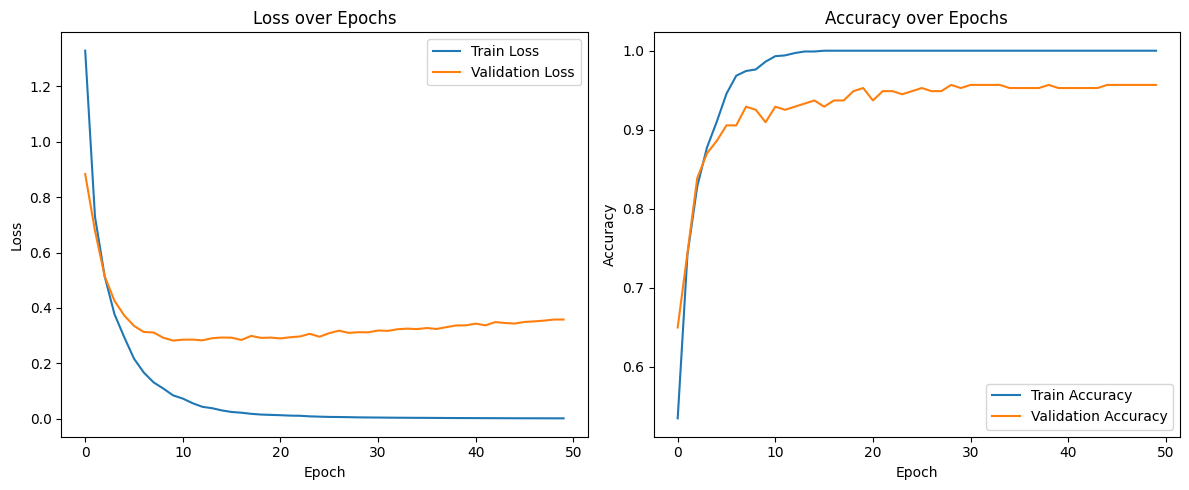

In [ ]:
# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label='Train Loss')
plt.plot(history["val_loss"], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label='Train Accuracy')
plt.plot(history["val_acc"], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()



1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is the forward pass, which computes gradients, which is the update rule?


optimizer.zero_grad()   

---

outputs = model(xb)  

Section 1 code     
```
z1 = x @ W1 + b1
h  = np.tanh(z1)
y_hat = h @ W2 + b2
```

---
loss = criterion(outputs, yb)           

Section 1 code     
```
loss  = np.mean((y_hat - y) ** 2)    
losses.append(loss)
```
---
loss.backward()

Section 1 code      
```
d_yhat = 2 * (y_hat - y) / len(y)
dW2 = h.T @ d_yhat
db2 = d_yhat.sum(axis=0)
dh  = d_yhat @ W2.T
dz1 = dh * (1 - np.tanh(z1) ** 2)     
dW1 = x.T @ dz1
db1 = dz1.sum(axis=0)
```
---
optimizer.step()     
Section 1 code  
```
  W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2
```



2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the specific numbers that back up your claim.    
The model has overfitted. This is because from the plotted graphs there is a considerable gap between the training accuracy and the validation accuracy. Also as the training error is  approaching 0 the validation error is making slow or no decrements to its error.
At Epoch 50/50 | Train loss 0.001, Train Acc: 1.000 | Val loss 0.358, Val Acc: 0.957.   
According to the report the model is performing very well in the training data but it struggles with useen data ie(validation data)

3. Why do we call optimizer.zero_grad() every batch? What silently goes wrong without it?
To reset the gadient for each epoch. If this isn't done the new gradients would add unto the old ones which would mess up the diretion we are going to optimise the weight.

# Part 2.4— Experiments: how training choices change the outcome

In [ ]:
# Wrap your Part 2.3 loop in a function first:


from typing import Dict, Any, Tuple
import torch.optim as optim
import torch.nn.functional as F
import torch.nn as nn
import torch

RANDOM_STATE = 42

input_dim = X_train_clf.shape[1]
NUM_CLASSES = int(y_train_clf.max() + 1)

class DroupoutNet(nn.Module):
    def __init__(self, input_dim: int, hidden_sizes: Tuple[int, ...], n_classes: int = 7, dropout_prob: float = 0.0):
        super().__init__()
        self.flatten = nn.Flatten()
        self.dropout_prob = dropout_prob

        layers = []
        current_dim = input_dim

        for i, h_size in enumerate(hidden_sizes):
            layers.append(nn.Linear(current_dim, h_size))
            layers.append(nn.ReLU())
            if self.dropout_prob > 0:
                layers.append(nn.Dropout(p=self.dropout_prob))
            current_dim = h_size

        # Output layer
        layers.append(nn.Linear(current_dim, n_classes))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = self.flatten(x)
        x = self.network(x)
        return x

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        correct += (outputs.argmax(1) == yb).sum().item()
        total += yb.size(0)


    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0
    all_preds, all_labels = [], []

    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        outputs = model(xb)
        loss = criterion(outputs, yb)

        running_val_loss += loss.item() * xb.size(0)
        preds = outputs.argmax(1)
        correct_val += (preds == yb).sum().item()
        total_val += yb.size(0)
        # Append predictions and labels to their respective lists
        all_preds.append(preds.cpu())
        all_labels.append(yb.cpu())

    va_loss = running_val_loss / total_val
    va_acc = correct_val / total_val
    preds = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()

    return va_loss, va_acc, preds, labels

def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
    model = DroupoutNet(input_dim, hidden_sizes, NUM_CLASSES, dropout)
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_loader_exp = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
    val_loader_exp = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=batch_size, shuffle=False)


    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader_exp, optimizer, criterion)
        va_loss, va_acc, _, _ = evaluate(model, val_loader_exp, criterion)
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

    return history

Training with capacity: Tiny (8,)
Training with capacity: Default (64, 32)
Training with capacity: Large (256, 128, 64)


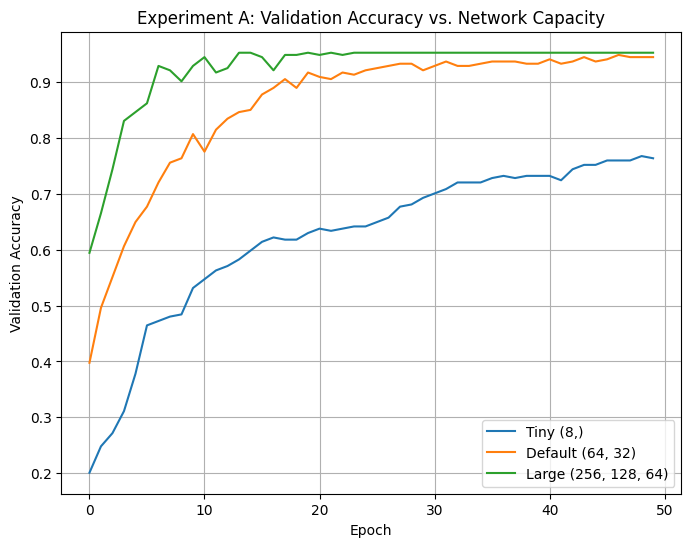

In [ ]:

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.


capacity_configs = {
    'Tiny (8,)': (8,),
    'Default (64, 32)': (64, 32),
    'Large (256, 128, 64)': (256, 128, 64)
}

capacity_histories = {}
for name, sizes in capacity_configs.items():
    print(f"Training with capacity: {name}")
    torch.manual_seed(RANDOM_STATE) # Ensure reproducibility for each config
    capacity_histories[name] = run_experiment(hidden_sizes=sizes, epochs=50)

plt.figure(figsize=(8, 6))
for name, history in capacity_histories.items():
    # Changed 'val_accuracies' to 'val_acc' to match the history dictionary structure
    plt.plot(history['val_acc'], label=name)
plt.title('Experiment A: Validation Accuracy vs. Network Capacity')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Training with learning rate of : LR 1e-4
Training with learning rate of : LR 1e-3
Training with learning rate of : LR 1e-1


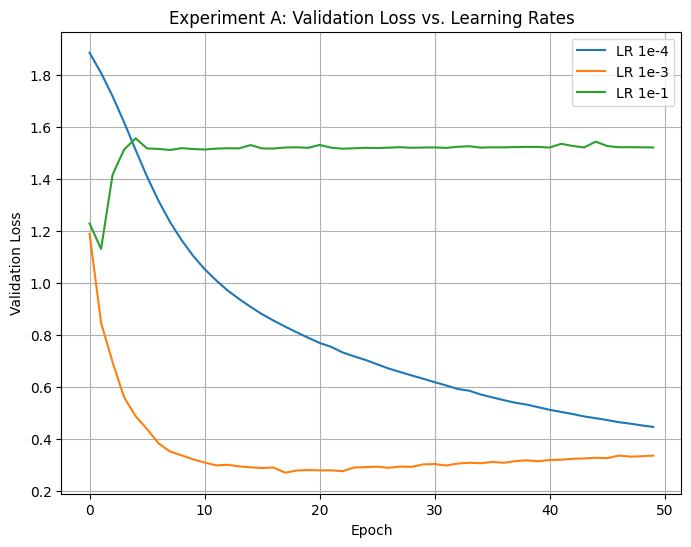

In [ ]:
# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.

learning_rates = {
    'LR 1e-4': 1e-4,
    'LR 1e-3': 1e-3,
    'LR 1e-1': 1e-1
}

learning_histories = {}
for name, lr_value in learning_rates.items():
    print(f"Training with learning rate of : {name}")
    torch.manual_seed(RANDOM_STATE)
    learning_histories[name] = run_experiment(hidden_sizes=(256, 128),lr = lr_value, epochs=50)

plt.figure(figsize=(8, 6))
for name, history in learning_histories.items():
    plt.plot(history['val_loss'], label=name)
plt.title('Experiment A: Validation Loss vs. Learning Rates')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.show()




Training with dropout probability of : With Dropout
Training with dropout probability of : Without Dropout


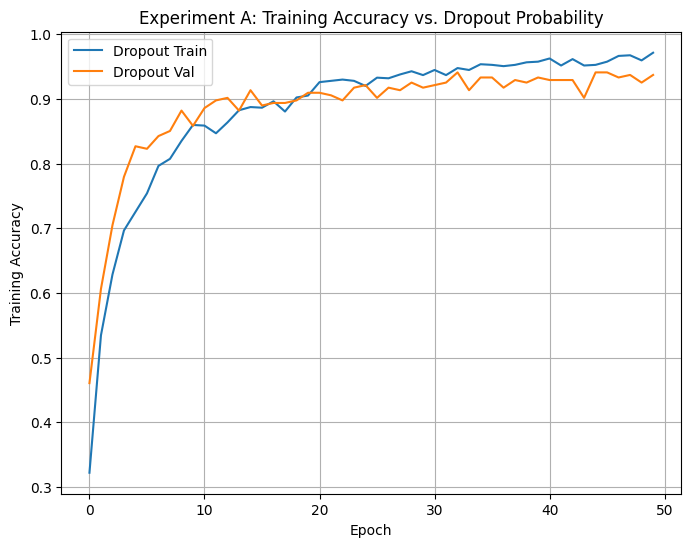

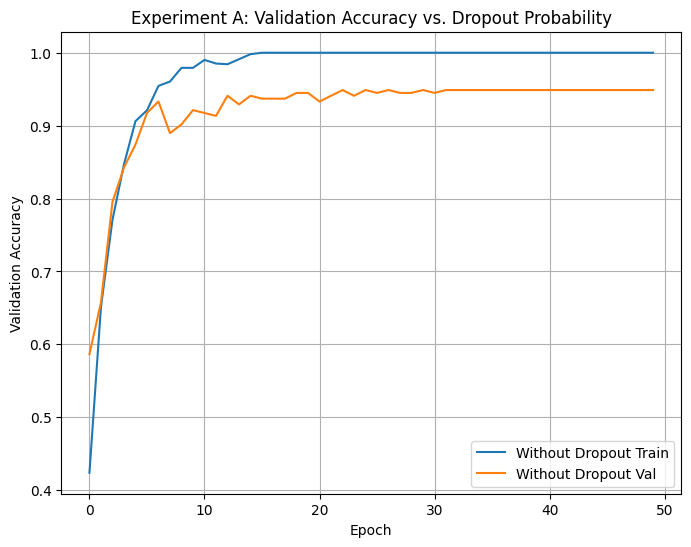

In [ ]:
# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.

dropout_prob = {
    'With Dropout': 0.3,
    'Without Dropout': 0.0,

}

dropout_histories = {}
for name, dropout_value in dropout_prob.items():
    print(f"Training with dropout probability of : {name}")
    torch.manual_seed(RANDOM_STATE)
    dropout_histories[name] = run_experiment(hidden_sizes=(256, 128, 64),dropout= dropout_value, epochs=50)


dropout_history = {}
dropout_history = run_experiment(hidden_sizes=(256, 128, 64), dropout = 0.3, epochs=50)

Withoutdropout_history = {}
Withoutdropout_history = run_experiment(hidden_sizes=(256, 128, 64), dropout = 0.0, epochs=50)

plt.figure(figsize=(8, 6))
plt.plot(dropout_history['train_acc'], label='Dropout Train')
plt.plot(dropout_history['val_acc'], label=f'Dropout Val')
plt.title('Experiment A: Training Accuracy vs. Dropout Probability')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 6))
plt.plot(Withoutdropout_history['train_acc'], label='Without Dropout Train')
plt.plot(Withoutdropout_history['val_acc'], label=f'Without Dropout Val')
plt.title('Experiment A: Validation Accuracy vs. Dropout Probability')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()


1. Capacity: did the largest network win on validation data? Where do you see diminishing returns or overfitting?   
The largest capacity won n the validation data because from the graph we see that it had the highest validation accuracy followed by the default before tiny.
Diminishing returns in the accuracy can be seen from epoch 10 to 50 for the larger capacity and from epoch 20 to 50 for the default capacity.


2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?    
The three regimes match what I saw on the toy problem. The larger learning rate(1e-1) increases the loss, whereas a smaller learning rate(1e-4) yields a more gradual decrease. The learning rate of 1e-3 has a more abrupt decreasing curve like what was seen for the 0.05 learning rate curve in Part 1.3.


3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two sentences HOW dropout achieves this.  
The the dropout closed the gap between the training and validation accuracy decreased meaning that the model did not overfit when some neurons where dropped out.   
Dropout acheives this by deliberately switching of some neurons activation to push the modell to learn through predictions from few data than memorising and overfiting.

# Part 2.5— Final evaluation and showdown with Lab 2


Test Accuracy: 0.9337
Test Macro-F1: 0.9322

Classification Report (Test Set)
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       109
           1       0.86      0.82      0.84       115
           2       0.82      0.88      0.85       116
           3       0.95      0.95      0.95       116
           4       0.94      0.97      0.96       140
           5       0.98      0.96      0.97       119
           6       1.00      0.98      0.99       130

    accuracy                           0.93       845
   macro avg       0.93      0.93      0.93       845
weighted avg       0.93      0.93      0.93       845



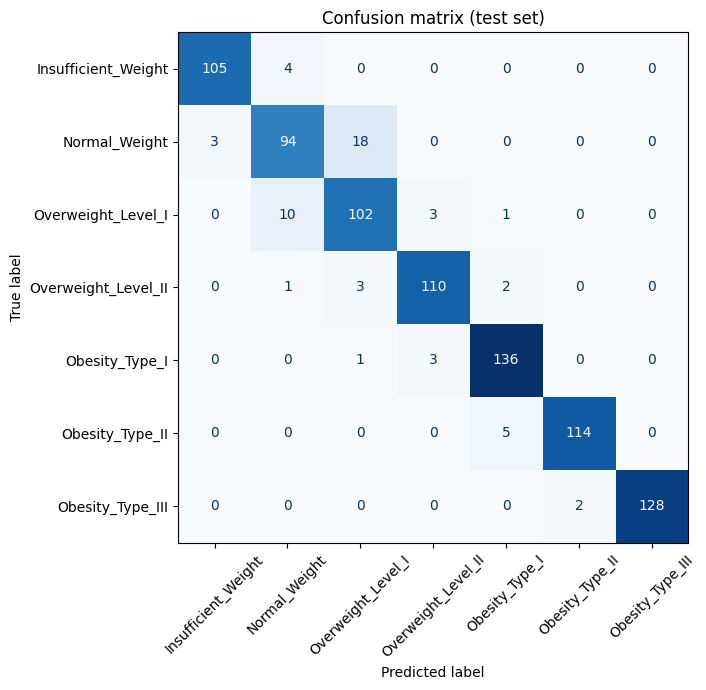


Comparison Table:


,Classifier,Test Accuracy,Test Macro-F1,Training Time(seconds),Number of Parameters
0,Best Lab 2 Classifier,0.8890,0.8890,0.1394,147
1,Neural Network,0.9337,0.9322,4.0000,117063


In [ ]:
from sklearn.metrics import accuracy_score, f1_score,confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn import model_selection

# TODO: Load your best configuration's weights; model.eval().
model_best = FeedForwardNet(input_dim=input_dim, hidden_sizes=(784, 128), n_classes=NUM_CLASSES)
model_best.load_state_dict(torch.load("ffn_best.pt"))
model_best.to(DEVICE)


criterion = nn.CrossEntropyLoss()
_, test_acc, preds, output = evaluate(model_best, test_loader, criterion)


# TODO: Report test ACCURACY and MACRO-F1
print(f"\nTest Accuracy: {test_acc:.4f}")
macro_f1 = f1_score(output, preds, average='macro')
print(f"Test Macro-F1: {macro_f1:.4f}")

print("\nClassification Report (Test Set)")
print(classification_report(output, preds))


# TODO: Confusion matrix for the test set with the 7 class names
# Confusion Matrix
cm = confusion_matrix(output, preds)
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III"
])
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
ax.set_title("Confusion matrix (test set)")
plt.tight_layout()
plt.show()


lab2_test_acc = 0.889
lab2_macro_f1 = 0.889
lab2_training_time = 0.1394
lab2_params = 147  # features (20) * num of classes(7) + bias(7)

# Number of parameters for the current neural network
nn_params = sum(p.numel() for p in model_best.parameters() if p.requires_grad)
nn_training_time = 4     # avg time


# TODO: Build a small comparison table (a pandas DataFrame is fine):
comparison_data = {
    'Classifier': ['Best Lab 2 Classifier', 'Neural Network'],
    'Test Accuracy': [lab2_test_acc, test_acc],
    'Test Macro-F1': [lab2_macro_f1, macro_f1],
    'Training Time(seconds)': [lab2_training_time, nn_training_time],
    'Number of Parameters': [lab2_params, nn_params]
}

comparison_df = pd.DataFrame(comparison_data)
print("\nComparison Table:")
comparison_df.round(4)


# Reflection

The black box, opened: Name the three most important things happening inside loss.backward() and optimizer.step(), in your own words.
In the loss.backward() and optimizer.step() we are
1. Traveling backwards from the output and loss to see how to adjust our gradients to get a lower loss.
2. Updating the weights using the learning rate and the computed gradient.
3. Setting the gradients to zero after each epoch


Hyperparameters: If you could tune only ONE hyperparameter on a new problem, which would you pick and why?
The hyperparameter I would tune is the dropout rate. This is because without it the model would try to memorise the data even with other hyperparameters being tuned.


Overfitting: Across your experiments, where did you see the biggest train-vs-validation gap, and which intervention reduced it most?
I saw the biggest train-vs-validation gap when I used a larger model in a fully connected feed forward network. The dropout function was the intervention that helped reduce it wher certain neurons where deactivated to prevent overfitting

Looking ahead: This network treats every input feature independently. Next lab we move to images, where nearby pixels are related. Why might a plain MLP struggle with images, and what property should a better architecture have?   
A plain MLP struggles because it fails to consider the local connectivity or relationships pixels in a region may be conveying. The plain MLP would convert the image into a single vector there by destroying its spatial structure and the locality relationship of the pixels. A better achitecture should probably have an attribute or function that allows for The model looks at the input as being dependent on the other inputs closest to it to have significance.

